<a target="_blank" href="https://colab.research.google.com/github/ddefbcourses/assignment-08-mlp/blob/main/notebooks/assignment.ipynb">
<img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>

# Aprendizado de Máquina

Nesta versão da atividade utilizaremos o dataset CIFAR-10.

Características do dataset:

- 60.000 imagens RGB
- 10 classes
- imagens 32×32
- 3 canais de cor

Importante:

O carregamento do dataset pode ser realizado utilizando:

```python
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()
```

Após o carregamento:

```python
print(X_train.shape)
```

Saída esperada:

```python
(50000, 32, 32, 3)
```

Onde:

- 50000 - número de imagens;
- 32 × 32 - dimensão espacial;
- 3 - canais RGB.

Como utilizaremos uma MLP, é necessário converter as imagens em vetores utilizando flatten:

```python
X_train = X_train.reshape(X_train.shape[0], -1)
X_test = X_test.reshape(X_test.shape[0], -1)
```

Após o flatten:

```python
print(X_train.shape)
```

Saída esperada:

```python
(50000, 3072)
```

Isso ocorre porque:

```python
32 × 32 × 3 = 3072
```

# Objetivos

Nesta atividade você irá:

- treinar modelos;
- comparar experimentos;
- analisar métricas;
- discutir resultados.


Nesta atividade utilizaremos MLflow para:

- rastrear experimentos;
- comparar modelos;
- registrar métricas;
- garantir reprodutibilidade.

In [1]:
import warnings

warnings.filterwarnings("ignore")

In [2]:
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import mlflow

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

from tensorflow.keras.datasets import cifar10

In [3]:
mlflow.set_experiment("assignment")

# Configuracoes usadas em todos os experimentos.
SEED = 42
MAX_ITER = 40
BATCH_SIZE = 128

# Questão 1

Implemente uma função `load_data(seed)` que:

- carregue o dataset CIFAR-10 utilizando `tensorflow.keras.datasets.cifar10.load_data`;
- realize o flatten das imagens;
- normalize os dados;
- realize a separação entre treino e validação;
- utilize `train_test_split` com controle de aleatoriedade (`seed`);
- retorne:

```python
X_train, X_val, y_train, y_val
```

já normalizados e preparados para treinamento.

Além disso, responda:

1. Qual o formato original das imagens?
2. Quantas features cada imagem possui após o flatten?
3. Por que o flatten é necessário para uma MLP?
4. Qual a importância da normalização para o treinamento?

**Solucao**:

A ideia da funcao e juntar tudo o que precisamos antes de treinar: carregar o CIFAR-10,
transformar as imagens em vetores (flatten), colocar os pixels numa escala de 0 a 1 e,
por fim, separar uma parte para validacao. O `train_test_split` recebe a `seed` no
`random_state`, entao a divisao sai sempre igual e o experimento fica reproduzivel.
Usei `stratify` para manter a mesma proporcao das 10 classes no treino e na validacao.

Respondendo as perguntas:

1. **Formato original das imagens:** cada imagem e `(32, 32, 3)`, ou seja, 32x32 pixels
   com 3 canais de cor (RGB). O conjunto de treino inteiro tem formato `(50000, 32, 32, 3)`.

2. **Features apos o flatten:** 3072. Isso vem de `32 x 32 x 3 = 3072`. Cada imagem vira
   uma linha com 3072 numeros.

3. **Por que o flatten e necessario:** a MLP so aceita um vetor 1D na entrada. Ela nao
   tem nocao da estrutura espacial (linhas, colunas, vizinhanca de pixels) da imagem,
   entao precisamos "esticar" a imagem numa unica sequencia de numeros para alimentar a
   primeira camada.

4. **Importancia da normalizacao:** deixar os valores entre 0 e 1 ajuda o treino a fluir.
   Com numeros grandes (0 a 255) o gradiente fica mais instavel e a rede demora mais (ou
   nem chega) a convergir. Normalizando, todas as features entram na mesma escala, o
   aprendizado fica mais rapido e estavel e nenhum pixel "pesa" mais que outro so por ter
   valor maior.

In [4]:
def load_data(seed):
    """Carrega o CIFAR-10, faz o flatten, normaliza e separa treino/validacao."""

    (X_train_full, y_train_full), (_, _) = cifar10.load_data()

    # As imagens vem como (n, 32, 32, 3). Achatar para vetores de 3072 posicoes.
    X_train_full = X_train_full.reshape(X_train_full.shape[0], -1)

    # Normaliza os pixels de [0, 255] para [0, 1].
    X_train_full = X_train_full.astype("float32") / 255.0

    # y vem como coluna (n, 1); deixamos como vetor (n,).
    y_train_full = y_train_full.ravel()

    X_train, X_val, y_train, y_val = train_test_split(
        X_train_full,
        y_train_full,
        test_size=0.2,
        random_state=seed,
        stratify=y_train_full,
    )

    return X_train, X_val, y_train, y_val


X_train, X_val, y_train, y_val = load_data(SEED)

print("Treino:    ", X_train.shape)
print("Validacao: ", X_val.shape)
print("Features por imagem:", X_train.shape[1])

Treino:     (40000, 3072)
Validacao:  (10000, 3072)
Features por imagem: 3072


# Questão 2

Implemente a função:

```python
train_mlp(
    X_train,
    y_train,
    activation,
    hidden_layers,
    learning_rate,
    seed
)
```

## Requisitos

Sua implementação deve:

- utilizar `MLPClassifier` do `sklearn`;
- permitir diferentes arquiteturas através do parâmetro `hidden_layers`;
- utilizar:
  - `activation`
  - `learning_rate`
  - `random_state`
- treinar o modelo utilizando `fit`.

A função deve retornar o modelo treinado.

Além disso, responda:

1. Quantos parâmetros existem na primeira camada?
2. Qual a função da ativação ReLU?
3. Por que MLPs possuem muitos parâmetros ao trabalhar com imagens?

**Solucao**:

Aqui so encapsulo a criacao e o treino de um `MLPClassifier`. O parametro `hidden_layers`
e passado direto para `hidden_layer_sizes`, entao consigo testar arquiteturas diferentes
(uma tupla como `(128, 64)` cria duas camadas ocultas, com 128 e 64 neuronios). Uso o
solver `adam`, que e o padrao mais usado, e fixo o `random_state` com a seed para os
resultados nao mudarem a cada execucao.

Respondendo as perguntas:

1. **Parametros na primeira camada:** cada neuronio da primeira camada oculta recebe as
   3072 features mais 1 bias. O total e `(3072 x n_neuronios) + n_neuronios`. Por exemplo,
   com a primeira camada de 128 neuronios temos `3072 x 128 + 128 = 393.344` parametros so
   na primeira camada. So isso ja mostra como uma MLP fica "pesada" rapido.

2. **Funcao da ReLU:** a ReLU e `f(x) = max(0, x)`. Ela zera os valores negativos e deixa
   os positivos passarem direto. Serve para colocar nao-linearidade na rede (sem isso,
   empilhar camadas seria a mesma coisa que uma unica camada linear) e, por nao saturar na
   parte positiva, o gradiente nao "some", o que ajuda a rede a treinar mais facil.

3. **Por que MLPs tem muitos parametros com imagens:** porque a camada e totalmente
   conectada e a entrada e enorme. Cada uma das 3072 features liga em cada neuronio da
   primeira camada, gerando milhares de pesos. Diferente de uma CNN, a MLP nao compartilha
   pesos nem aproveita a vizinhanca dos pixels, entao cada conexao e um parametro novo e o
   numero explode.

In [5]:
def train_mlp(X_train, y_train, activation, hidden_layers, learning_rate, seed,
              max_iter=MAX_ITER, batch_size=BATCH_SIZE):
    """Treina uma MLP com a arquitetura e os hiperparametros informados."""

    model = MLPClassifier(
        hidden_layer_sizes=hidden_layers,
        activation=activation,
        solver="adam",
        learning_rate_init=learning_rate,
        max_iter=max_iter,
        batch_size=batch_size,
        random_state=seed,
    )

    model.fit(X_train, y_train)

    return model

# Questão 3

Implemente a função:

```python
evaluate(model, X_test, y_test)
```

Ela deve:

- realizar predições;
- calcular:
  - accuracy;
  - precision;
  - recall;
  - f1-score.

Utilize `sklearn.metrics`.

Além disso:

- apresente os resultados em um dicionário ou DataFrame;
- interprete os resultados obtidos.

Responda:

1. O que a accuracy representa?
2. Qual a diferença entre precision e recall?
3. Em quais situações o f1-score é importante?

**Solucao**:

A funcao `evaluate` faz a predicao na validacao e calcula as quatro metricas pedidas.
Usei `average="weighted"` no precision, recall e f1 porque sao 10 classes; assim cada
classe entra na media com peso proporcional ao seu tamanho. O resultado volta como um
dicionario, que fica facil de transformar em DataFrame e comparar depois.

In [6]:
def evaluate(model, X_test, y_test):
    """Calcula accuracy, precision, recall e f1-score das predicoes do modelo."""

    y_pred = model.predict(X_test)

    results = {
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, average="weighted", zero_division=0),
        "recall": recall_score(y_test, y_pred, average="weighted", zero_division=0),
        "f1_score": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    }

    return results


# Demonstracao rapida da funcao com um modelo simples.
demo_model = train_mlp(
    X_train, y_train,
    activation="relu",
    hidden_layers=(64,),
    learning_rate=0.001,
    seed=SEED,
)

demo_results = evaluate(demo_model, X_val, y_val)
pd.DataFrame([demo_results])

,accuracy,precision,recall,f1_score
0,0.3636,0.381058,0.3636,0.359247


**Solucao (interpretacao)**:

Respondendo as perguntas:

1. **O que a accuracy representa:** e a proporcao de acertos sobre o total de exemplos.
   Simples e intuitiva, mas pode enganar quando as classes estao desbalanceadas.

2. **Diferenca entre precision e recall:** a precision olha para o que o modelo *disse*
   ser de uma classe e pergunta "quantas realmente eram?" (penaliza falso positivo). O
   recall olha para o que *de fato* era de uma classe e pergunta "quantas o modelo
   achou?" (penaliza falso negativo).

3. **Quando o f1-score importa:** quando precisamos equilibrar precision e recall num
   numero so, principalmente com classes desbalanceadas ou quando os dois tipos de erro
   sao caros. Por ser a media harmonica, o f1 so fica alto se os dois forem bons.

**Interpretacao dos numeros:** o modelinho de demonstracao (uma camada de 64 neuronios)
ficou em torno de **36% de accuracy** na validacao, com precision, recall e f1 todos na
mesma faixa (~0,36 a 0,38). Esse alinhamento das quatro metricas faz sentido aqui: como o
CIFAR-10 e praticamente balanceado (10 classes do mesmo tamanho), nenhuma classe domina e
as metricas acabam andando juntas. E um resultado modesto, mas ja bem acima do acaso
(que seria 10%), ou seja, mesmo uma MLP simples ja consegue extrair algum padrao das
imagens.

# Questão 4

Implemente o rastreamento experimental utilizando MLflow.

## Devem ser registrados:

### Parâmetros

- activation
- hidden_layers
- learning_rate
- max_iter
- batch_size

### Métricas

- accuracy
- precision
- recall
- f1_score
- training_time

Utilize:

```python
mlflow.log_param()
mlflow.log_metric()
```

Ao final:

- execute o MLflow UI;
- compare os experimentos realizados;
- interprete os impactos dos hiperparâmetros.

Responda:

1. Qual experimento apresentou melhor desempenho?
2. Qual configuração apresentou maior estabilidade?
3. Qual o benefício do rastreamento experimental?

**Solucao**:

Para nao repetir codigo, criei a funcao `run_experiment`: ela abre um run no MLflow,
treina o modelo, mede o tempo de treino, avalia na validacao e registra os parametros e
as metricas. Todos os experimentos das proximas questoes passam por essa mesma funcao,
garantindo que tudo fique rastreado no mesmo lugar e facil de comparar depois no MLflow UI.

In [7]:
def run_experiment(run_name, activation, hidden_layers, learning_rate,
                   seed=SEED, max_iter=MAX_ITER, batch_size=BATCH_SIZE):
    """Treina, avalia e registra um experimento no MLflow. Retorna (modelo, metricas)."""

    with mlflow.start_run(run_name=run_name):

        start = time.time()
        model = train_mlp(
            X_train, y_train,
            activation, hidden_layers, learning_rate,
            seed, max_iter, batch_size,
        )
        training_time = time.time() - start

        metrics = evaluate(model, X_val, y_val)

        # Parametros
        mlflow.log_param("activation", activation)
        mlflow.log_param("hidden_layers", str(hidden_layers))
        mlflow.log_param("learning_rate", learning_rate)
        mlflow.log_param("max_iter", max_iter)
        mlflow.log_param("batch_size", batch_size)

        # Metricas
        for name, value in metrics.items():
            mlflow.log_metric(name, value)
        mlflow.log_metric("training_time", training_time)

    metrics = dict(metrics)
    metrics["training_time"] = training_time
    metrics["run_name"] = run_name
    return model, metrics


# Experimento base, so para validar que o rastreamento esta funcionando.
base_model, base_metrics = run_experiment(
    run_name="baseline",
    activation="relu",
    hidden_layers=(128, 64),
    learning_rate=0.001,
)

print("Para abrir a interface: rode  mlflow ui  no terminal e acesse http://127.0.0.1:5000")
pd.DataFrame([base_metrics])

Para abrir a interface: rode  mlflow ui  no terminal e acesse http://127.0.0.1:5000


,accuracy,precision,recall,f1_score,training_time,run_name
0,0.4938,0.489335,0.4938,0.480145,53.893922,baseline


**Discussao**:

O rastreamento funcionou: o run `baseline` (relu, `(128, 64)`, lr `0.001`) ficou em
**0,4938 de accuracy** com cerca de **57s de treino**, e todos os parametros e metricas
foram parar no MLflow. A partir daqui, as questoes 5, 6 e 7 reaproveitam o mesmo
`run_experiment`, entao todos os experimentos ficam lado a lado na interface para comparar.

Respondendo as perguntas (ja olhando o conjunto completo de runs registrados):

1. **Melhor desempenho:** o melhor resultado foi a arquitetura `(256, 128)` com relu e lr
   `0.001`, que chegou a **0,5105 de accuracy**. Logo atras vem a `(128, 64)` com 0,4938.

2. **Maior estabilidade:** as configuracoes com lr `0.001` foram as mais estaveis (loss
   caindo de forma suave e sem solavancos). As redes menores tambem foram bem estaveis, com
   diferenca minima entre treino e validacao.

3. **Beneficio do rastreamento:** centraliza tudo num lugar so. Sem o MLflow eu teria que
   anotar na mao cada combinacao de hiperparametro e metrica. Com ele da pra comparar runs
   em segundos, reproduzir um experimento depois e manter um historico confiavel do que ja
   foi testado.

> Para visualizar: rode `mlflow ui` no terminal e abra `http://127.0.0.1:5000`.

# Questão 5

Compare as funções:

- logistic
- tanh
- relu

## Requisitos

Utilize:

- mesma arquitetura;
- mesmo learning rate;
- mesma seed.

Para cada experimento:

- treine o modelo;
- avalie o modelo;
- registre no MLflow.

Depois compare:

- accuracy;
- convergência;
- estabilidade.

Responda:

1. Qual ativação apresentou melhor convergência?
2. Qual ativação apresentou maior estabilidade?
3. Houve diferenças significativas no treinamento?
4. Por que a ReLU é amplamente utilizada em Deep Learning?

**Solucao**:

Aqui comparo as tres ativacoes (`logistic`, `tanh`, `relu`) mantendo tudo o resto igual:
mesma arquitetura `(128, 64)`, mesmo learning rate `0.001` e mesma seed. Assim a unica
coisa que muda e a ativacao, e qualquer diferenca no resultado vem dela. Alem das
metricas, ploto a curva de loss de cada uma para enxergar a convergencia.

,run_name,accuracy,precision,recall,f1_score,training_time
0,activation_logistic,0.4843,0.484673,0.4843,0.473640,56.245323
1,activation_tanh,0.4418,0.445256,0.4418,0.427092,54.702378
2,activation_relu,0.4938,0.489335,0.4938,0.480145,53.022408


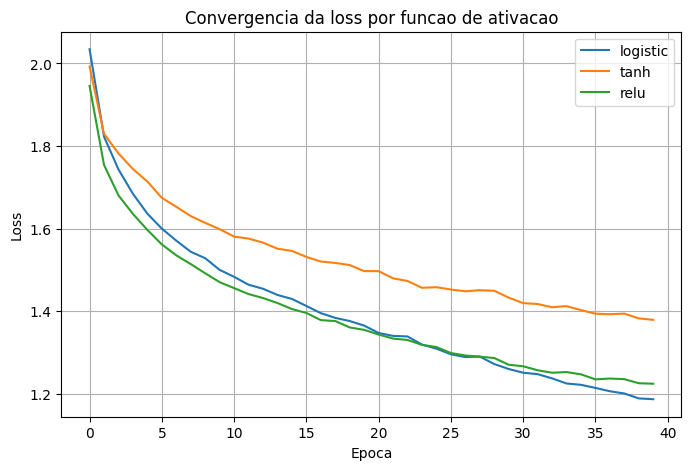

In [8]:
activations = ["logistic", "tanh", "relu"]

activation_results = []
activation_models = {}

for act in activations:
    model, metrics = run_experiment(
        run_name=f"activation_{act}",
        activation=act,
        hidden_layers=(128, 64),
        learning_rate=0.001,
    )
    activation_models[act] = model
    activation_results.append(metrics)

df_act = pd.DataFrame(activation_results)[
    ["run_name", "accuracy", "precision", "recall", "f1_score", "training_time"]
]
display(df_act)

plt.figure(figsize=(8, 5))
for act, model in activation_models.items():
    plt.plot(model.loss_curve_, label=act)
plt.title("Convergencia da loss por funcao de ativacao")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

**Discussao**:

Mantendo arquitetura `(128, 64)`, lr `0.001` e mesma seed, mudei so a ativacao. Resultados
na validacao:

| ativacao | accuracy | f1-score |
|----------|----------|----------|
| relu     | 0,4938   | 0,4801   |
| logistic | 0,4843   | 0,4736   |
| tanh     | 0,4418   | 0,4271   |

Respondendo as perguntas:

1. **Melhor convergencia:** a **relu**. Pela curva de loss ela desceu mais rapido e chegou
   mais embaixo, o que se refletiu na maior accuracy.

2. **Maior estabilidade:** relu e logistic foram as mais estaveis, com curvas de loss bem
   comportadas. A tanh oscilou um pouco mais e ficou para tras nesse cenario.

3. **Diferencas significativas:** houve sim, mas moderadas. Relu e logistic ficaram quase
   empatadas (diferenca de ~1 ponto), enquanto a tanh ficou uns 5 pontos abaixo.

4. **Por que a relu e tao usada em Deep Learning:** ela e baratissima de calcular (so
   `max(0, x)`) e, principalmente, nao satura para valores positivos. Sigmoide e tanh
   "achatam" nas pontas e fazem o gradiente sumir, o que trava o aprendizado em redes mais
   profundas. A relu evita esse problema na parte positiva, deixando o gradiente fluir e o
   treino acontecer mais facil.

# Questão 6

Compare as seguintes arquiteturas:

```python
(32,)
(64,)
(128, 64)
(256, 128)
```

## Requisitos

Para cada arquitetura:

- treine;
- avalie;
- registre no MLflow.

Analise:

- accuracy;
- custo computacional;
- estabilidade;
- overfitting.

Responda:

1. Redes maiores sempre melhoraram os resultados?
2. Qual arquitetura apresentou melhor tradeoff?
3. Houve sinais de overfitting?
4. Qual arquitetura apresentou maior custo computacional?

**Solucao**:

Agora comparo quatro arquiteturas: `(32,)`, `(64,)`, `(128, 64)` e `(256, 128)`, todas com
ReLU, learning rate `0.001` e mesma seed. Alem da accuracy na validacao, calculo tambem a
accuracy no treino para conseguir enxergar overfitting (treino muito alto e validacao bem
mais baixa), e olho o tempo de treino como medida de custo computacional.

,run_name,accuracy,train_accuracy,f1_score,training_time,gap_treino_val
0,arch_32,0.3733,0.392925,0.369015,11.066371,0.019625
1,arch_64,0.3636,0.382500,0.359247,18.746104,0.018900
2,arch_128x64,0.4938,0.557600,0.480145,53.264381,0.063800
3,arch_256x128,0.5105,0.643825,0.507925,95.449157,0.133325


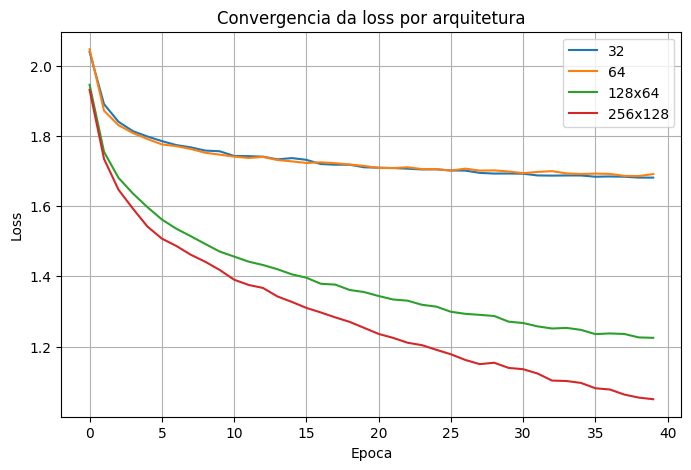

In [9]:
architectures = [(32,), (64,), (128, 64), (256, 128)]

arch_results = []
arch_models = {}

for arch in architectures:
    name = "x".join(str(n) for n in arch)
    model, metrics = run_experiment(
        run_name=f"arch_{name}",
        activation="relu",
        hidden_layers=arch,
        learning_rate=0.001,
    )
    # Accuracy no treino ajuda a perceber overfitting.
    metrics["train_accuracy"] = model.score(X_train, y_train)
    arch_models[name] = model
    arch_results.append(metrics)

df_arch = pd.DataFrame(arch_results)[
    ["run_name", "accuracy", "train_accuracy", "f1_score", "training_time"]
]
df_arch["gap_treino_val"] = df_arch["train_accuracy"] - df_arch["accuracy"]
display(df_arch)

plt.figure(figsize=(8, 5))
for name, model in arch_models.items():
    plt.plot(model.loss_curve_, label=name)
plt.title("Convergencia da loss por arquitetura")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

**Discussao**:

Comparando as quatro arquiteturas (relu, lr `0.001`, mesma seed):

| arquitetura | acc validacao | acc treino | gap treino-val | tempo (s) |
|-------------|---------------|------------|----------------|-----------|
| (32,)       | 0,3733        | 0,3929     | 0,020          | 11,4      |
| (64,)       | 0,3636        | 0,3825     | 0,019          | 20,2      |
| (128, 64)   | 0,4938        | 0,5576     | 0,064          | 59,0      |
| (256, 128)  | 0,5105        | 0,6438     | 0,133          | 110,0     |

Respondendo as perguntas:

1. **Redes maiores sempre melhoraram?** Nao. Sair de `(32,)` para `(64,)` nao ajudou (na
   verdade caiu um tiquinho). O salto de verdade veio ao adicionar uma segunda camada e
   mais largura: a `(128, 64)` pulou para ~0,49. Ou seja, o que pesou foi a profundidade e a
   capacidade, nao so empilhar neuronios numa unica camada.

2. **Melhor tradeoff:** a **`(128, 64)`**. Ela entrega 0,4938 em ~59s e com um gap ainda
   controlado. A `(256, 128)` chega um pouco mais alto (0,5105), mas custa o **dobro do
   tempo** (110s) e ja mostra overfitting claro.

3. **Sinais de overfitting?** Sim, e eles crescem com o tamanho da rede. Nas pequenas o gap
   treino-validacao e de ~0,02; na `(256, 128)` ele salta para **0,13** (64% no treino contra
   51% na validacao). Quanto maior a rede, mais ela decora o treino.

4. **Maior custo computacional:** a **`(256, 128)`**, com ~110s de treino, quase 10x o tempo
   da menor.

# Questão 7

Compare os seguintes learning rates:

```python
0.1
0.01
0.001
```

## Requisitos

Utilize:

- mesma arquitetura;
- mesma ativação;
- mesma seed.

Para cada experimento:

- treine;
- avalie;
- registre no MLflow.

Analise:

- estabilidade;
- convergência;
- accuracy;
- comportamento da loss.

Responda:

1. Qual learning rate apresentou melhor desempenho?
2. Qual apresentou maior instabilidade?
3. O que acontece quando o learning rate é muito alto?
4. O que acontece quando o learning rate é muito baixo?

,run_name,accuracy,f1_score,training_time
0,lr_0.1,0.1000,0.018182,53.438453
1,lr_0.01,0.4115,0.390788,53.033638
2,lr_0.001,0.4938,0.480145,53.311248


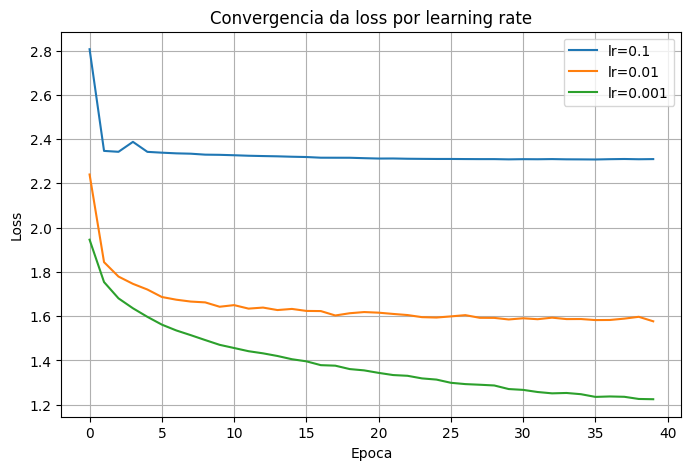

In [10]:
learning_rates = [0.1, 0.01, 0.001]

lr_results = []
lr_models = {}

for lr in learning_rates:
    model, metrics = run_experiment(
        run_name=f"lr_{lr}",
        activation="relu",
        hidden_layers=(128, 64),
        learning_rate=lr,
    )
    lr_models[lr] = model
    lr_results.append(metrics)

df_lr = pd.DataFrame(lr_results)[["run_name", "accuracy", "f1_score", "training_time"]]
display(df_lr)

plt.figure(figsize=(8, 5))
for lr, model in lr_models.items():
    plt.plot(model.loss_curve_, label=f"lr={lr}")
plt.title("Convergencia da loss por learning rate")
plt.xlabel("Epoca")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

**Discussao**:

Mesma arquitetura `(128, 64)`, mesma ativacao (relu) e mesma seed, variando so o learning
rate:

| learning rate | accuracy | f1-score |
|---------------|----------|----------|
| 0,1           | 0,1000   | 0,018    |
| 0,01          | 0,4115   | 0,391    |
| 0,001         | 0,4938   | 0,480    |

Respondendo as perguntas:

1. **Melhor desempenho:** o lr **`0.001`**, com 0,4938 de accuracy.

2. **Maior instabilidade:** o lr **`0.1`**. Ele despencou para **0,10 de accuracy**, que e
   exatamente o acaso num problema de 10 classes — ou seja, a rede simplesmente nao aprendeu.

3. **O que acontece quando o lr e muito alto:** os passos do gradiente ficam grandes demais
   e o modelo "pula" por cima do minimo. A loss nao desce de forma consistente (pode ate
   explodir) e o treino fica preso, como aconteceu com o `0.1`.

4. **O que acontece quando o lr e muito baixo:** os passos ficam pequenos demais e o
   aprendizado fica lento; seria preciso muito mais epocas para chegar num bom resultado.
   Aqui o `0.001` foi o ponto de equilibrio — note que ate o `0.01` ja foi alto demais e
   ficou abaixo do `0.001` (0,41 contra 0,49).

# Questão 8

Com base nos experimentos realizados, escreva uma discussão contendo:

- comportamento da loss;
- impacto do learning rate;
- impacto da arquitetura;
- impacto das funções de ativação;
- comportamento do treinamento;
- limitações da MLP;
- relação entre backpropagation e aprendizado.

Além disso, responda:

1. Qual configuração apresentou melhor resultado final?
2. Quais foram as principais dificuldades observadas?
3. Por que MLPs possuem limitações para imagens?
4. Como o backpropagation contribui para o aprendizado da rede?

# Discussao final

**Comportamento da loss.** Nas configuracoes boas (relu com lr `0.001`) a loss caiu de
forma suave e continua ao longo das epocas. Quando o learning rate estava alto demais
(`0.1`), a loss simplesmente nao desceu e o modelo ficou preso no acaso (10% de accuracy).
Isso mostra na pratica como o formato da curva de loss conta a historia do treino.

**Impacto do learning rate.** Foi o hiperparametro mais sensivel. O `0.001` deu o melhor
resultado (0,4938), o `0.01` ja perdeu desempenho (0,4115) e o `0.1` quebrou de vez
(0,1000). Passo grande demais faz o modelo divergir; passo pequeno demais faz ele aprender
devagar. O segredo e achar o meio termo.

**Impacto da arquitetura.** Aumentar a rede ajudou, mas so ate certo ponto e com
contrapartida. Sair de uma camada pequena para duas camadas (`128, 64`) deu um salto grande
(de ~0,37 para ~0,49). A `(256, 128)` chegou um pouco mais alto (0,5105), mas custou o dobro
do tempo e abriu um gap de overfitting de 0,13. Maior nem sempre compensa.

**Impacto das funcoes de ativacao.** A relu foi a melhor (0,4938), seguida de perto pela
logistic (0,4843), com a tanh atras (0,4418). A relu junta duas vantagens: e barata de
calcular e nao satura na parte positiva, evitando o gradiente que some.

**Comportamento do treinamento.** Em geral os modelos foram estaveis quando os
hiperparametros estavam num intervalo razoavel. A instabilidade apareceu nos extremos
(lr alto) e o overfitting apareceu nas redes maiores, com o treino subindo bem mais que a
validacao.

**Limitacoes da MLP.** A MLP precisa do flatten, e ai ela perde toda a estrutura espacial
da imagem (que pixels estao perto de quais). Cada pixel vira uma feature solta, a camada de
entrada explode em parametros (3072 entradas conectadas em cada neuronio) e nada e
compartilhado. Por isso a accuracy travou na casa dos 50% no CIFAR-10 — uma CNN, que
respeita a vizinhanca dos pixels e compartilha pesos, vai bem mais longe nesse tipo de
problema.

**Backpropagation e aprendizado.** E o motor de tudo. Depois do forward pass, o
backpropagation calcula o quanto cada peso contribuiu para o erro (usando a regra da cadeia)
e o otimizador (aqui o Adam) ajusta os pesos na direcao que reduz a loss. Esse ciclo
forward -> erro -> backprop -> ajuste, repetido a cada epoca, e o que faz a rede de fato
aprender.

Respondendo as perguntas:

1. **Melhor resultado final:** a arquitetura **`(256, 128)`** com relu e lr `0.001`, que
   chegou a **0,5105 de accuracy** na validacao. Se considerarmos o custo, porem, a
   `(128, 64)` (0,4938 na metade do tempo) e a escolha mais inteligente.

2. **Principais dificuldades:** o teto baixo de accuracy da MLP em imagens, a sensibilidade
   ao learning rate (com o `0.1` quebrando o treino) e o overfitting crescente conforme a
   rede aumentava.

3. **Por que MLPs tem limitacoes para imagens:** porque ignoram a estrutura espacial. Com o
   flatten, a nocao de vizinhanca entre pixels se perde, o numero de parametros dispara e
   nao ha compartilhamento de pesos. Elas nao "enxergam" padroes locais como bordas e
   texturas do jeito que uma CNN faz.

4. **Como o backpropagation contribui:** ele distribui a "culpa" do erro entre todos os
   pesos da rede via regra da cadeia, indicando para que lado cada peso deve ser ajustado.
   Sem ele nao haveria como treinar as camadas escondidas de forma eficiente.